<a href="https://colab.research.google.com/github/ncskr2003/2026_tues-bigdatacomputing_class_20220767/blob/main/7%EC%A3%BC%EC%B0%A8_%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B6%84%EC%84%9D%ED%8C%8C%EC%9D%B4%ED%94%84%EB%9D%BC%EC%9D%B8_%EC%A0%95%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 시험 유형 - 빈칸 채우기 , 실행 결과 적기

- 알고리즘 구조, 사용법 알기
- 해석하는 위주로 공부하기
- 시험일 - 4월 21일 14시 진행

✅ [7주차 실습] 날씨 데이터 분석 파이프라인 및 엑셀 저장 완성하기
- 데이터 생성 → 전처리 → 분석 → 시각화 -> 파일로 저장
- numpy를 이용해 가상의 시계열 날씨 데이터를 생성
- 시계열 데이터 분석 관련 주요 함수
  - **df.to_excel()**:
    - 여러 개의 분석 결과를 하나의 엑셀 파일(.xlsx) 안에 시트별로 나누어 저장
    - **pd.ExcelWriter()** 를 사용
  - **df.to_csv(encoding='utf-8-sig')** :
    - 전처리가 끝난 "깨끗한" 내부 데이터를 다시 csv 파일로 저장
  - **pd.read_csv(encoding='cp949')** :
    -  외부에서 데이터를 가져오는 것()     
  - **zip()** :
    - 여러 개의 리스트(또는 반복 가능한 객체)를 같은 순서 인덱스끼리 짝을 지어 묶어주는 내장 함수
    - 보통 여러 데이터를 동시에 for문으로 처리할 때 가장 많이 사용     
  - **pd.to_datetime()** :
    - 문자열 "2023-01-01"을 '연/월/일/시/분/초' 날짜 객체 타입으로 변경
    - **df.set_index()** :
      - 데이터프레임의 일반 컬럼을 '인덱스'로 설정
    - 이 두 과정(날짜 데이터변환-> 날짜 기준 인덱스 설정)을 통해 판다스가 날짜를 이해하는 시계열 데이터가 완성    
  - **df[컬럼].interpolate()** :
    - 결측치가 발생했을 때, 앞의 데이터와 뒤의 데이터를 선으로 이어서 그 선 위에 있는 값을 결측치로 논리적으로 채우는 방식
    - 기온, 주가, 센서 데이터처럼 앞뒤 값이 연속성을 가질 때 사용.
    - fillna()로 특정 숫자를 채울 때보다 데이터의 추세를 훨씬 잘 보존
  - **df.rolling()**:
    - '움직이는 창'을 설정해 그 안의 값들을 계산하는 슬라이딩 윈도우 기능
    - 데이터의 급격한 변동을 줄이고 전체적인 추세를 파악.    
  - **Min-Max Scaling**:
    - 서로 다른 범위를 가진 수치 데이터를 0과 1 사이의 일정한 범위로 변환
    - 최소값은 0, 최대값은 1이 되도록 선형적으로 변환.
  - **df.map()** :
    - 시리즈나 인덱스의 각 요소를 하나씩 꺼내어 특정 규칙(함수 또는 딕셔너리)에 통과시킨 뒤, 그 결과값으로 치환하는 기능.   
  - **df.index.month**:
    - 시계열 인덱스에서 'Month' 정보만 뽑아내는 기능.
  - **sns.histplot()**:
    - 데이터가 특정 구간에 얼마나 많이 쌓여 있는지(빈도)를 보여줌
    - **kde=True** 옵션을 넣으면 부드러운 곡선을 그려주어 전체적인 분포의 형태를 쉽게 파악.
  - **sns.heatmap()**:
    - 수치로 가득 찬 표를 색상으로 변환
  - 데이터프레임 결합
    - pd.concat(axis = , join = )
    - df1.merge(df2 , on = , how = )
    - df.pivot_table(index = , column = , values = ).sum()

## 데이터 프레임 결합



In [87]:
# 데이터 프레임 결합
import pandas as pd
import numpy as np

# 1. 데이터 준비 : A 지점에서 1월 1일부터 3일간 수집한 기온
df_a = pd.DataFrame({
    'date' : pd.to_datetime(['2023-01-01', '2023-01-02' , '2023-01-03']),
    'temp' : [10, 12, 13],
    'location' : ['A', 'A', 'A']
})
print("\n", df_a)

# 2. 시계열 데이터프레임 준비 : B 지점에서 1월 2일부터 4일간 수집한 기온 ( 날짜가 A와 일부 겹침)
df_b = pd.DataFrame({
    'date' : pd.to_datetime(['2023-01-02', '2023-01-03' , '2023-01-04']),
    'temp' : [15, 16, 14],
    'location' : ['B', 'B' ,'B'] })

print("\n", df_b)

# 3. 물리적으로 모든 지역에서 수집한 기온 통합
df = pd.concat([df_a, df_b], axis= 0, join="outer")
print("\n", df)

# df = pd.concat([df_a, df_b], axis= 0, join="inner")

# 4. 'date' 컬럼을 기준으로 "겹치는 날짜"에 정보를 포함하는 테이블
df_merged = df_a.merge(df_b, on = 'date', how = 'inner', suffixes= ("_A", "_B"))
print("\n", df_merged)

df_merged = df_a.merge(df_b, on = 'date', how = 'outer', suffixes= ("_A", "_B"))
print("\n", df_merged)

# 5. df의 데이터를 사용하여 날짜별/지점별 기온 표 만들기 : pivot_table()
df_summary = df.pivot_table(index = 'date', columns= 'location', values = 'temp').sum()
print("\n", df_summary)


         date  temp location
0 2023-01-01    10        A
1 2023-01-02    12        A
2 2023-01-03    13        A

         date  temp location
0 2023-01-02    15        B
1 2023-01-03    16        B
2 2023-01-04    14        B

         date  temp location
0 2023-01-01    10        A
1 2023-01-02    12        A
2 2023-01-03    13        A
0 2023-01-02    15        B
1 2023-01-03    16        B
2 2023-01-04    14        B

         date  temp_A location_A  temp_B location_B
0 2023-01-02      12          A      15          B
1 2023-01-03      13          A      16          B

         date  temp_A location_A  temp_B location_B
0 2023-01-01    10.0          A     NaN        NaN
1 2023-01-02    12.0          A    15.0          B
2 2023-01-03    13.0          A    16.0          B
3 2023-01-04     NaN        NaN    14.0          B

 location
A    35.0
B    45.0
dtype: float64


```python
import pandas as pd
import numpy as np

# 1. A 지점 데이터
df_a = pd.DataFrame({
    'date': pd.to_datetime(['2023-01-01', '2023-01-02', '2023-01-03']),
    'temp': [10, 12, 13],
    'location': ['A', 'A', 'A']
})
print(df_a)

# 2. B 지점 데이터
df_b = pd.DataFrame({
    'date': pd.to_datetime(['2023-01-02', '2023-01-03', '2023-01-04']),
    'temp': [15, 16, 14],
    'location': ['B', 'B', 'B']
})
print(df_b)

# 3. 행 방향 결합
df = pd.concat([df_a, df_b], axis=0, join='outer')
print(df)

# 4. date 기준 병합
df_merged_inner = df_a.merge(df_b, on='date', how='inner', suffixes=('_A', '_B'))
print(df_merged_inner)

df_merged_outer = df_a.merge(df_b, on='date', how='outer', suffixes=('_A', '_B'))
print(df_merged_outer)

# 5. 날짜별 / 지점별 기온 요약표
df_summary = df.pivot_table(index='date', columns='location', values='temp')
print(df_summary)
```

---

### 1) 코드 설명 (흐름)

#### `pd.concat([df_a, df_b], axis=0)`
- 두 데이터프레임을 **아래로 이어붙임**
- 즉, 행(row) 기준 결합

#### `merge(on='date')`
- `date` 컬럼이 같은 행끼리 **가로로 합침**
- 공통 날짜를 기준으로 정보 연결

#### `pivot_table(index='date', columns='location', values='temp')`
- 날짜를 행으로
- 지점을 열로
- 기온을 값으로 하는 요약표 생성

---

### 2) 알고리즘 (동작 원리)

#### (1) concat 알고리즘
```text
데이터프레임 A의 아래에 데이터프레임 B를 붙인다
```

예:
```text
A: 2023-01-01, 10, A
A: 2023-01-02, 12, A
B: 2023-01-02, 15, B
B: 2023-01-03, 16, B
```

즉, **세로 결합**

---

#### (2) merge 알고리즘
```text
기준 컬럼(date)이 같은 행끼리 연결한다
```

예: inner merge
```text
2023-01-02 → A의 데이터 + B의 데이터 연결
2023-01-03 → A의 데이터 + B의 데이터 연결
```

즉, **가로 결합**

---

#### (3) pivot_table 알고리즘
```text
행 기준(index), 열 기준(columns), 값(values)을 정해서 표를 재구성한다
```

예:
```text
        A     B
1/1    10   NaN
1/2    12   15
1/3    13   16
1/4   NaN   14
```

---

### 3) 개념 설명

#### `concat()`
- 데이터프레임을 단순히 붙이는 함수
- 구조가 비슷한 표 여러 개를 합칠 때 사용

#### `merge()`
- 공통된 키(기준 컬럼)를 중심으로 결합
- 데이터베이스의 JOIN과 같은 개념

#### `pivot_table()`
- 데이터를 요약해서 새로운 표 형태로 바꾸는 함수
- 행/열/값 구조를 재배치

---

### 4) 시험 포인트

#### `concat`
```python
pd.concat([df1, df2], axis=0)
```
- `axis=0` → 행 방향 결합
- `axis=1` → 열 방향 결합

#### `merge`
```python
df1.merge(df2, on='기준열', how='inner')
```
- `inner` : 공통 부분만
- `outer` : 전체 다
- `left` : 왼쪽 기준
- `right` : 오른쪽 기준

#### `suffixes`
```python
suffixes=('_A', '_B')
```
- 같은 열 이름이 있을 때 구분용 접미사 추가

#### `pivot_table`
```python
df.pivot_table(index='행기준', columns='열기준', values='값')
```

---


## CSV & Excel 입출력

In [24]:
#df.to_csv() & pd.read_csv() , df.to_axcel()
import pandas as pd

# 1. 데이터 생성
data = { '도시' : [ '서울', '부산' ,'제주'],
        '평균기온' : [15.2 , 18.5 , 20.1]}
df = pd.DataFrame(data)
print("\n", df)

# 2. df -> csv파일 저장( to_csv() )
df.to_csv("sample_data.csv",index = False, encoding = "utf-8-sig")

# 3. csv -> df 형태로 다시 읽어 오기 ( read_csv() )
loaded_df = pd.read_csv("sample_data.csv", encoding = "utf-8-sig") # CP949 차이점
print("\n", loaded_df)

# 4. 엑셀 파일로 저장하기 ( df.to_axcel() )
with pd.ExcelWriter("final_report.xlsx") as f:
  # 각 테이블을 서로 다른 시트 이름으로 저장
  loaded_df.to_excel(f,sheet_name = "날씨 데이터", index = False)
  df.to_excel(f,sheet_name = "전체 데이터", index = False)
  loaded_df.to_excel(f, sheet_name = "데이터분석 결과", index = False)


    도시  평균기온
0  서울  15.2
1  부산  18.5
2  제주  20.1

    도시  평균기온
0  서울  15.2
1  부산  18.5
2  제주  20.1




```python
import pandas as pd

# 1. 데이터 생성
data = {
    '도시': ['서울', '부산', '제주'],
    '평균기온': [15.2, 18.5, 20.1]
}

df = pd.DataFrame(data)
print(df)

# 2. DataFrame → CSV 저장
df.to_csv("sample_data.csv", index=False, encoding="utf-8-sig")

# 3. CSV → DataFrame 불러오기
loaded_df = pd.read_csv("sample_data.csv", encoding="utf-8-sig")
print(loaded_df)

# 4. Excel 파일 저장 (여러 시트)
with pd.ExcelWriter("final_report.xlsx") as f:
    loaded_df.to_excel(f, sheet_name="날씨 데이터", index=False)
    df.to_excel(f, sheet_name="전체 데이터", index=False)
    loaded_df.to_excel(f, sheet_name="데이터분석 결과", index=False)
```

---

### 1) 코드 설명 (흐름)

- `pd.DataFrame(data)`  
  → 딕셔너리 → 데이터프레임 변환

- `to_csv()`  
  → 데이터프레임을 CSV 파일로 저장

- `read_csv()`  
  → CSV 파일을 다시 데이터프레임으로 불러오기

- `ExcelWriter()`  
  → 하나의 엑셀 파일 안에 여러 시트 생성

- `to_excel()`  
  → 시트별로 데이터 저장

---

### 2) 알고리즘 (동작 개념)

#### CSV 저장/불러오기 흐름
1. DataFrame → 파일 형태(CSV)로 변환  
2. 파일 → 다시 DataFrame으로 복원  

#### Excel 저장 흐름
1. Excel 파일 생성  
2. 시트별로 데이터 작성  
3. 파일 저장

---

### 3) 개념 설명

- CSV : 텍스트 기반 데이터 파일 (쉼표로 구분)
- Excel : 시트(sheet) 구조를 가진 파일

- `to_csv()` / `read_csv()`  
→ **파일 ↔ 데이터프레임 변환**

- `to_excel()`  
→ 엑셀 형식으로 저장

- `ExcelWriter`  
→ 여러 시트 저장할 때 사용

---

### 시험 포인트

- `index=False`  
→ 인덱스 열 제거 (안 쓰면 열 하나 추가됨)

- `encoding="utf-8-sig"`  
→ 한글 깨짐 방지

- `cp949` vs `utf-8-sig` 차이 자주 출제

- 여러 시트 저장  
→ `ExcelWriter` 필수

- 오타 주의  
```python
to_axcel ❌
to_excel ✅
```

---

### 한 줄 요약
DataFrame ↔ 파일 변환 = `to_csv / read_csv`  
엑셀 여러 시트 = `ExcelWriter + to_excel`

## zip()

In [23]:
# zip()
names = ['서울', '부산', '제주']
temps = [15.5 , 18.2 ,20.1]
# zip으로 묶기 -> 리스트의 동일 인덱스에 있는 것끼리 묶어서 하나의 튜플로 반환
zipped = zip(names, temps)
#print(list(zipped))

# 용도
for name, temp in zipped:
  print(f"({name},{temp})")


(서울,15.5)
(부산,18.2)
(제주,20.1)


```python
# 리스트 정의
names = ['서울', '부산', '제주']
temps = [15.5 , 18.2 ,20.1]

# zip으로 묶기
zipped = zip(names, temps)

# 사용 (언패킹)
for name, temp in zipped:
    print(f"({name}, {temp})")
```

---

### 1) 코드 설명 (흐름)

- `zip(names, temps)`  
  → 두 리스트의 같은 인덱스끼리 묶어서 튜플 생성

- `(name, temp)`  
  → 튜플을 자동으로 분리 (언패킹)

- `for문`  
  → 묶인 데이터를 하나씩 꺼내서 출력

---

### 2) 알고리즘 (동작 원리)

```
names[i], temps[i] → (names[i], temps[i])
```

예:
```
('서울', 15.5)
('부산', 18.2)
('제주', 20.1)
```

👉 같은 위치(i)끼리 묶는 구조

---

### 3) 개념 설명

- `zip()` = 여러 리스트를 **병렬로 묶는 함수**
- 결과는 **튜플 형태**
- 반복문에서 자주 사용됨

---

### 시험 포인트

- zip은 **이터레이터 → 한 번만 사용 가능**
```python
z = zip(names, temps)
list(z)
list(z)  # → []
```

- 길이가 다르면 → 짧은 쪽 기준
```python
zip(['A','B'], [1,2,3])
→ [('A',1), ('B',2)]
```

- 출력하려면 `list()` 필요
```python
list(zip(names, temps))
```

---

### 한 줄 요약
`zip()` = 같은 인덱스끼리 묶어서 튜플로 만드는 함수

## datetime 변환 & 인덱스 설정

In [22]:
#pd.to_datetime() ,df.set_index()
import pandas as pd
# 1. 시계열 데이터 생성
df = pd.DataFrame( {'date' : ['2025-01-01' ,'2025-01-02','2025-01-03'],
                    'temp': [10, 11, 12]})
print("\n", df)
print("\n", df['date'].dtype) # pandas 문자열 자료형 : object
# 2. object => datetime64 (날짜객체타입)
df['date_time'] = pd.to_datetime(df['date'])
print("\n", df)
print("\n", df['date_time'].dtype)
# date_time을 데이터프레임의 새 인덱스로 설정 ( set_index() )
df.set_index('date_time' , inplace = True)
print('\n', df)
# 4. 월 정보를 추출
print(df.index.day)


          date  temp
0  2025-01-01    10
1  2025-01-02    11
2  2025-01-03    12

 object

          date  temp  date_time
0  2025-01-01    10 2025-01-01
1  2025-01-02    11 2025-01-02
2  2025-01-03    12 2025-01-03

 datetime64[ns]

                   date  temp
date_time                   
2025-01-01  2025-01-01    10
2025-01-02  2025-01-02    11
2025-01-03  2025-01-03    12
Index([1, 2, 3], dtype='int32', name='date_time')


```python
import pandas as pd

# 1. 데이터 생성
df = pd.DataFrame({
    'date': ['2025-01-01', '2025-01-02', '2025-01-03'],
    'temp': [10, 11, 12]
})

print(df)
print(df['date'].dtype)   # object (문자열)

# 2. 문자열 → datetime 변환
df['date_time'] = pd.to_datetime(df['date'])
print(df)
print(df['date_time'].dtype)   # datetime64

# 3. 인덱스 설정
df.set_index('date_time', inplace=True)
print(df)

# 4. 날짜 정보 추출
print(df.index.day)
```

---

### 1) 코드 설명 (흐름)

- `df['date']`  
  → 문자열(object) 형태의 날짜 데이터

- `pd.to_datetime()`  
  → 문자열 → 날짜형(datetime64) 변환

- `set_index()`  
  → 특정 열을 인덱스로 설정

- `df.index.day`  
  → 인덱스에서 날짜 정보 추출

---

### 2) 알고리즘 (동작 원리)

```
문자열 → datetime 변환 → 인덱스로 설정 → 날짜 정보 추출
```

단계:
1. 문자열 날짜 파싱
2. datetime 객체 생성
3. 인덱스로 설정
4. 속성(day, month 등) 접근

---

### 3) 개념 설명

- pandas 기본 날짜 타입 → `object` (문자열)
- `datetime64` → 날짜 계산 가능한 타입

- 날짜 인덱스를 사용하면:
  - 시간 기반 분석 가능
  - 날짜별 그룹화 / 필터링 가능

---

### 시험 포인트

- 변환 함수
```python
pd.to_datetime()
```

- 인덱스 설정
```python
df.set_index('col', inplace=True)
```

- 날짜 정보 추출
```python
df.index.year
df.index.month
df.index.day
```

- `inplace=True` → 원본 변경

---

### 한 줄 요약
문자열 날짜 → `to_datetime()` → 인덱스 설정 → 날짜 속성 사용

## 결측치 처리 (fillna / interpolate)

In [38]:
# df.interpolate() : 결측치를 선형적으로 보간하기
# fillna() => 평균값이나 특정값으로 채우기
import pandas as pd
import numpy as np

# 1. 시계열 데이터 준비
data = {'temp' : [10.0 , 12.0, np.nan, np.nan , 16.0 ,18.0]}
df = pd.DataFrame(data)
print("\n", df)

# 2. 결측치 전처리 !!!
# (1) 결측치를 평균값 대체
df['temp_fill_mean'] = df['temp'].fillna(df['temp'].mean())
print("\n",df)

# (2) 선형보간으로 결측치 처리n
df['temp_fill_linear'] = df['temp'].interpolate(method = 'linear')
print("\n",df)





    temp
0  10.0
1  12.0
2   NaN
3   NaN
4  16.0
5  18.0

    temp  temp_fill_mean
0  10.0            10.0
1  12.0            12.0
2   NaN            14.0
3   NaN            14.0
4  16.0            16.0
5  18.0            18.0

    temp  temp_fill_mean  temp_fill_linear
0  10.0            10.0         10.000000
1  12.0            12.0         12.000000
2   NaN            14.0         13.333333
3   NaN            14.0         14.666667
4  16.0            16.0         16.000000
5  18.0            18.0         18.000000


```python
import pandas as pd
import numpy as np

# 1. 데이터 생성 (결측치 포함)
data = {'temp': [10.0, 12.0, np.nan, np.nan, 16.0, 18.0]}
df = pd.DataFrame(data)
print(df)

# 2. 결측치 처리

# (1) 평균값으로 채우기
df['temp_fill_mean'] = df['temp'].fillna(df['temp'].mean())

# (2) 선형 보간
df['temp_fill_linear'] = df['temp'].interpolate(method='linear')

print(df)
```

---

### 1) 코드 설명 (흐름)

- `np.nan`  
  → 결측치(비어있는 값)

- `fillna(mean())`  
  → 결측치만 평균값으로 대체

- `interpolate()`  
  → 앞뒤 값을 기준으로 중간값 계산

---

### 2) 알고리즘 (동작 원리)

#### 평균값 채우기
```
결측치 → 전체 평균값으로 대체
```

#### 선형 보간
```
결측치 = 앞 값과 뒤 값 사이를 직선으로 연결해서 계산
```

예:
```
12 → NaN → NaN → 16
→ 12, 13.33, 14.66, 16
```

---

### 3) 개념 설명

- 결측치 처리 방법 2가지
  1. `fillna()` → 고정값 채우기
  2. `interpolate()` → 흐름 기반 보간

- `interpolate()`는 시계열 데이터에서 많이 사용

---

### 시험 포인트

- 결측치 표현 → `np.nan`

- 평균 채우기
```python
df['col'].fillna(df['col'].mean())
```

- 선형 보간
```python
df['col'].interpolate(method='linear')
```

- 차이
  - fillna → 일정한 값
  - interpolate → 자연스럽게 변화

---

### 한 줄 요약
결측치 처리 = `fillna(고정값)` vs `interpolate(연속값 기반)`

## rolling() (이동 평균 + 확인 출력)




         temp
0  28.820262
1  22.000786
2  24.893690
3  31.204466
4  29.337790

          temp  7day_avg_temp
0   28.820262            NaN
1   22.000786            NaN
2   24.893690            NaN
3   31.204466            NaN
4   29.337790            NaN
5   15.113611            NaN
6   24.750442      25.160149
7   19.243214      23.792000
8   19.483906      23.432445
9   22.052993      23.026632
10  20.720218      21.528882
11  27.271368      21.233679
12  23.805189      22.475333
13  20.608375      21.883609
14  22.219316      22.308766
15  21.668372      22.620833
16  27.470395      23.394747
17  18.974209      23.145318
18  21.565339      22.330171
19  15.729521      21.176504


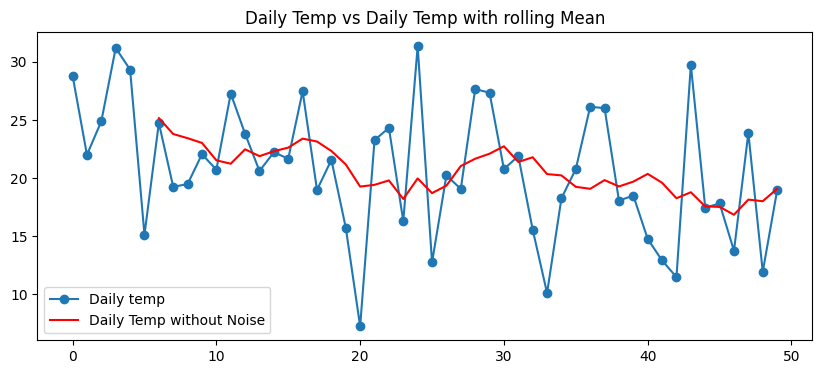

In [40]:
# df.rolling(window=)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1, 50일 간의 기온을 생성
np.random.seed(0)
df = pd.DataFrame({'temp' : np.random.normal(20 ,5,50)})
print("\n" , df.head())

# 7일치 기온 데이터를 묶어서 기온의 평균을 구하여 열로 추가
df['7day_avg_temp'] = df['temp'].rolling(window = 7 ).mean()
print("\n" , df.head(20))

#2.시각화
# 선 그래프 시각화
plt.figure(figsize = (10, 4))
plt.plot(df['temp'] , label = 'Daily temp' , marker = 'o')
plt.plot(df['7day_avg_temp'] , label = "Daily Temp without Noise", color = "red")
plt.title("Daily Temp vs Daily Temp with rolling Mean")
plt.legend()
plt.show()

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 생성 (50일 기온)
np.random.seed(0)
df = pd.DataFrame({'temp': np.random.normal(20, 5, 50)})
print(df.head())

# 2. 이동 평균 (7일)
df['7day_avg_temp'] = df['temp'].rolling(window=7).mean()
print(df.head(20))   # NaN 확인

# 3. 시각화
plt.figure(figsize=(10, 4))
plt.plot(df['temp'], label='Daily temp', marker='o')
plt.plot(df['7day_avg_temp'], label="7-day Moving Avg", color="red")
plt.title("Daily Temp vs Rolling Mean")
plt.legend()
plt.show()
```

---

### 1) 코드 설명 (흐름)

- `np.random.normal(20, 5, 50)`  
  → 평균 20, 표준편차 5인 랜덤 데이터 50개 생성

- `rolling(window=7)`  
  → 7개씩 묶어서 계산 준비

- `.mean()`  
  → 7일 이동 평균 계산

- `df.head(20)`  
  → 앞부분 NaN 확인

- `plt.plot()`  
  → 원본 vs 이동 평균 시각화

---

### 2) 알고리즘 (동작 원리)

```
i번째 값 = 이전 7개 데이터의 평균
```

예:
```
[1,2,3,4,5,6,7] → 평균
[2,3,4,5,6,7,8] → 평균
```

👉 창(window)이 이동하면서 평균 계산

---

### 3) 개념 설명

- 이동 평균 = **데이터를 부드럽게 만드는 방법**
- 급격한 변화(노이즈)를 줄이고 **전체 흐름(추세)** 확인

---

### 시험 포인트

- 기본 형태
```python
df['col'].rolling(window=n).mean()
```

- 앞부분 NaN 발생
→ 이유: 데이터 부족 (n개 미만)

- 용도
  - 시계열 분석
  - 추세 파악

---

### 한 줄 요약
`rolling(n).mean()` = n개 평균으로 데이터 흐름을 부드럽게 만든다

## Min-Max Scaling (정규화)

In [46]:
# Min-Max scaling : 데이터 전처리 작업에서 필요
import pandas as pd
import numpy as np

# 1. 기온과 강수량 데이터 준비
data = {
    'temp' : [-10, 0 , 15, 25, 35],   # -10 ~ 35
    'rainfall' : [0, 50, 100, 200, 300]   # 0 ~ 300
}

df = pd.DataFrame(data)
print("\n", df)

# 2. 0 ~ 1 사이의 범위로 변환 (최소값 -> 0, 최대값 -> 1)
def min_max_scale(series) :
  result = (series - series.min()) / (series.max() - series.min())
  return result

df['temp_scaled'] = min_max_scale(df['temp'])
df['rainfall_scaled'] = min_max_scale(df['rainfall'])

print("\n", df)


    temp  rainfall
0   -10         0
1     0        50
2    15       100
3    25       200
4    35       300

    temp  rainfall  temp_scaled  rainfall_scaled
0   -10         0     0.000000         0.000000
1     0        50     0.222222         0.166667
2    15       100     0.555556         0.333333
3    25       200     0.777778         0.666667
4    35       300     1.000000         1.000000



```python
import pandas as pd
import numpy as np

# 1. 데이터 생성
data = {
    'temp': [-10, 0, 15, 25, 35],
    'rainfall': [0, 50, 100, 200, 300]
}

df = pd.DataFrame(data)
print(df)

# 2. Min-Max Scaling 함수
def min_max_scale(series):
    result = (series - series.min()) / (series.max() - series.min())
    return result

# 3. 정규화 적용
df['temp_scaled'] = min_max_scale(df['temp'])
df['rainfall_scaled'] = min_max_scale(df['rainfall'])

print(df)
```

---

### 1) 코드 설명 (흐름 이해)

- `pd.DataFrame(data)`  
  → 딕셔너리를 데이터프레임으로 변환

- `series.min()` / `series.max()`  
  → 해당 열의 최소값 / 최대값 구함

- `(series - series.min())`  
  → 모든 값에서 최소값을 빼서 **기준을 0으로 이동**

- `(series.max() - series.min())`  
  → 전체 데이터 범위 계산

- 나누기 `/`  
  → 값들을 **0 ~ 1 사이로 변환**

- `df['temp_scaled']`  
  → 정규화된 새로운 열 추가

---

### 2) 알고리즘 (시험 핵심)

```
(현재값 - 최소값) / (최대값 - 최소값)
```

#### 처리 과정
1. 최소값 기준으로 이동 (shift)
2. 전체 범위로 나눔 (scale)
3. 결과 → 0 ~ 1 사이 값

---

### 3) 개념 설명

- Min-Max Scaling = **데이터 정규화 방법**
- 서로 단위가 다른 데이터를 **같은 기준(0~1)**으로 맞춤

#### 왜 쓰냐?
- 온도 (-10~35) vs 강수량 (0~300)  
→ 스케일이 달라서 비교 어려움  
→ 정규화하면 동일 기준으로 비교 가능

---

### 시험 포인트
- 공식 그대로 기억
```python
(x - min) / (max - min)
```

- 결과 범위 → **0 ~ 1**
- 최소값 → 0, 최대값 → 1

---

### 한 줄 요약
Min-Max Scaling = 값을 "비율로 변환해서 0~1로 맞추는 것"

## map() (값 변환)

In [48]:
# se.map()
import pandas as pd

# 샘플 점수 성적 데이터
df = pd.DataFrame( { 'score' : [45, 56, 88, 79, 95] })

# 60점 미만이면 "fail" , 아니면 "pass"
def check_score(se):
  if se < 60:
    return "fail"
  else:
    return "pass"

# map 적용
df['result'] = df['score'].map(check_score)
print(df)

   score result
0     45   fail
1     56   fail
2     88   pass
3     79   pass
4     95   pass


```python
import pandas as pd

# 1. 데이터 생성
df = pd.DataFrame({'score': [45, 56, 88, 79, 95]})

# 2. 조건 함수 정의
def check_score(se):
    if se < 60:
        return "fail"
    else:
        return "pass"

# 3. map 적용
df['result'] = df['score'].map(check_score)

print(df)
```

---

### 1) 코드 설명 (흐름)

- `df['score']`  
  → 점수 데이터 (Series)

- `check_score()`  
  → 점수를 받아서 pass / fail 반환

- `map(check_score)`  
  → 각 값에 함수 적용

- `df['result']`  
  → 결과를 새로운 열로 저장

---

### 2) 알고리즘 (동작 원리)

```
각 요소에 대해 함수 적용
```

예:
```
45 → fail
56 → fail
88 → pass
```

👉 하나씩 꺼내서 함수 실행 → 결과 반환

---

### 3) 개념 설명

- `map()` = **각 값에 함수 또는 규칙 적용**
- Series(열) 단위로 작동
- 값 변환할 때 사용

---

### 시험 포인트

- 기본 형태
```python
df['col'].map(function)
```

- 함수 대신 딕셔너리도 가능
```python
df['col'].map({45:'fail', 56:'fail'})
```

- `map()` vs `apply()`
  - map → **Series 전용**
  - apply → DataFrame도 가능

---

### 한 줄 요약
`map()` = 각 값에 함수를 적용해서 새로운 값으로 변환

## 날짜 생성 + 요일 처리 + groupby() + 시각화



                  temp  day
2026-03-01  10.939540    6
2026-03-02  13.628526    0
2026-03-03  16.484222    1
2026-03-04  17.829944    2
2026-03-05  21.596253    3

                  temp  day day_eng
2026-03-01  10.939540    6     Sun
2026-03-02  13.628526    0     Mon
2026-03-03  16.484222    1     Tue
2026-03-04  17.829944    2     Wed
2026-03-05  21.596253    3     Thu


/tmp/ipykernel_1168/2851156191.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df ,x = 'day_eng' , y = 'temp', palette = 'Set2')


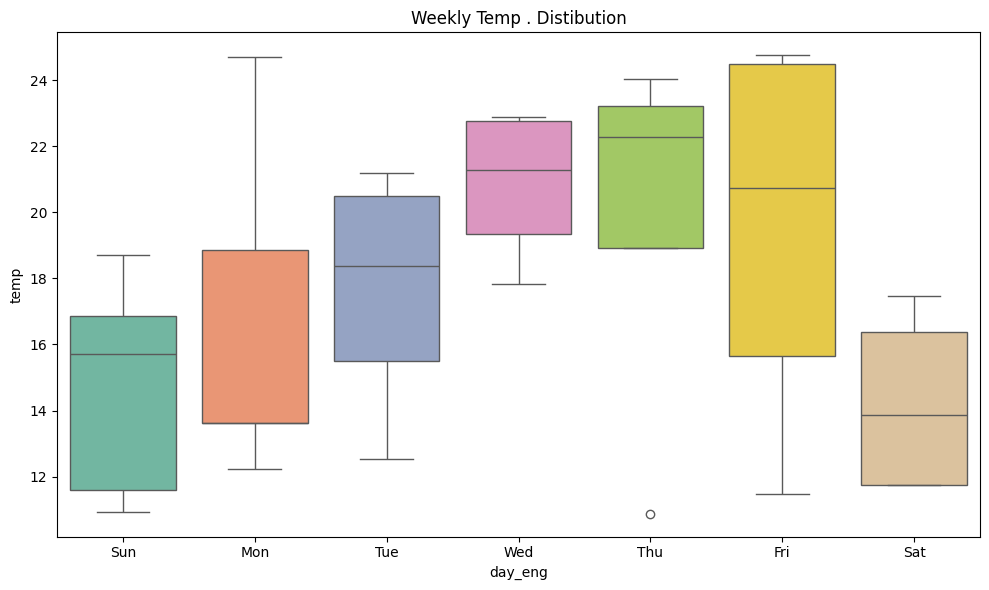


 day_eng
Fri    19.412673
Mon    16.602773
Sat    14.240249
Sun    14.764348
Thu    19.860674
Tue    17.618648
Wed    20.824335
Name: temp, dtype: float64


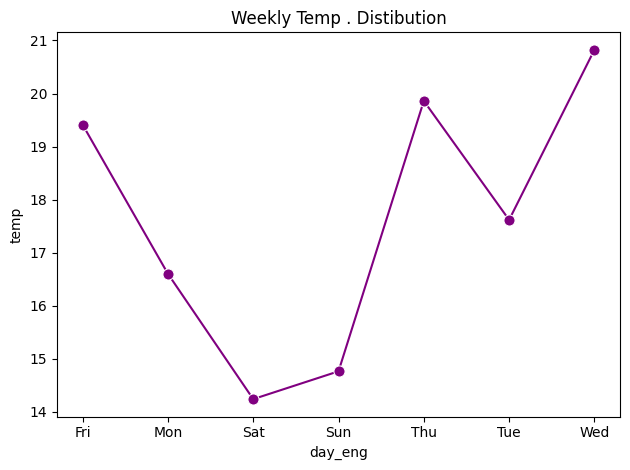

In [72]:
# pd.date_range(), df.index.dateofweek , se.reindex()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 1. 30일치 날짜 기온 데이터
dates = pd.date_range(start ="2026-03-01" , periods= 30) # 날짜
df = pd.DataFrame({
    "temp": np.random.uniform(10, 25, 30)}, index = dates) # pd.to_datetime()은 필요 없음
df['day'] = df.index.dayofweek # 요일 정보 추출
print("\n", df.head())

# 2. 숫자 요일(0,1,2.....6) -> 영어 요일명으로 매핑
day_names = {0:'Mon',1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
df['day_eng'] = df.index.dayofweek.map(day_names)
print("\n", df.head())

# 3. 요일별 기온 분포 그래프 시각화 ( sns.boxplot() )
plt.figure(figsize = (10, 6))
sns.boxplot(data = df ,x = 'day_eng' , y = 'temp', palette = 'Set2')
plt.title("Weekly Temp . Distibution")
plt.tight_layout()
plt.show()

# 4. 요일별 / 평균 기온 집계를 이용하여 시각화 ( sns.lineplot() )
# (1) 요일별 기온 평균 집계
weekly_temp_mean = df.groupby('day_eng')['temp'].mean()
print("\n", weekly_temp_mean)
sns.lineplot(weekly_temp_mean, marker = 'o' , color = 'purple'  , markersize = 8)

plt.title("Weekly Temp . Distibution")
plt.tight_layout()
plt.show()



```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 30일치 날짜 데이터 생성
dates = pd.date_range(start="2026-03-01", periods=30)

# 2. 날짜를 인덱스로 하는 데이터프레임 생성
df = pd.DataFrame({
    "temp": np.random.uniform(10, 25, 30)
}, index=dates)

# 3. 요일 정보 추출 (0=월 ~ 6=일)
df['day'] = df.index.dayofweek
print(df.head())

# 4. 숫자 요일 → 영어 요일명 매핑
day_names = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
df['day_eng'] = df['day'].map(day_names)
print(df.head())

# 5. 요일별 기온 분포 시각화
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='day_eng', y='temp', palette='Set2')
plt.title("Weekly Temp Distribution")
plt.tight_layout()
plt.show()

# 6. 요일별 평균 기온 계산
weekly_temp_mean = df.groupby('day_eng')['temp'].mean()
print(weekly_temp_mean)

# 7. 요일별 평균 기온 시각화
sns.lineplot(x=weekly_temp_mean.index, y=weekly_temp_mean.values,
             marker='o', color='purple')
plt.title("Weekly Mean Temperature")
plt.tight_layout()
plt.show()
```

---

### 1) 코드 설명 (흐름)

- `pd.date_range()`  
  → 일정한 기간의 날짜를 자동 생성

- `index=dates`  
  → 날짜를 데이터프레임의 인덱스로 설정

- `df.index.dayofweek`  
  → 각 날짜의 요일 번호 추출  
  → 월=0, 화=1, ..., 일=6

- `map(day_names)`  
  → 숫자 요일을 영어 문자열로 변환

- `sns.boxplot()`  
  → 요일별 기온 분포 시각화

- `groupby('day_eng')['temp'].mean()`  
  → 요일별 평균 기온 계산

- `sns.lineplot()`  
  → 평균값의 흐름을 선 그래프로 표현

---

### 2) 알고리즘 (동작 원리)

#### 전체 흐름
```text
날짜 생성
→ 날짜를 인덱스로 저장
→ 인덱스에서 요일 추출
→ 숫자 요일을 이름으로 변환
→ 요일별로 데이터 묶기
→ 평균 계산
→ 그래프로 시각화
```

#### groupby 알고리즘
```text
같은 요일끼리 묶는다
→ 각 요일 그룹의 temp 값들을 모은다
→ 평균을 계산한다
```

예:
```text
Mon → [14.2, 18.5, 20.1] → 평균
Tue → [13.7, 17.9, 21.0] → 평균
```

---

### 3) 개념 설명

#### `pd.date_range()`
- 일정 범위의 날짜를 자동 생성하는 함수
- 시계열 데이터 만들 때 자주 사용

#### `dayofweek`
- 날짜에서 요일 정보를 숫자로 뽑는 속성
- 월요일이 0부터 시작

#### `map()`
- 기존 값을 다른 값으로 바꾸는 함수
- 여기서는 숫자 요일 → 영어 요일명으로 변환

#### `groupby()`
- 같은 값끼리 묶어서 평균, 합계 같은 집계 수행
- SQL의 `GROUP BY`와 같은 개념

#### `boxplot`
- 데이터의 분포를 보여주는 그래프
- 중앙값, 범위, 이상치 등을 확인 가능

#### `lineplot`
- 평균값이나 추세를 선으로 표현하는 그래프

---

### 4) 시험 포인트

- 날짜 생성
```python
pd.date_range(start="2026-03-01", periods=30)
```

- 요일 추출
```python
df.index.dayofweek
```

- 매핑
```python
df['day'].map(day_names)
```

- 그룹별 평균
```python
df.groupby('day_eng')['temp'].mean()
```

- 시각화 종류 구분
  - `boxplot` → 분포
  - `lineplot` → 평균/추세

---

### 5) 코드에서 주의할 점

#### (1) 오타
```python
df.index.dateofweek ❌
df.index.dayofweek ✅
```

#### (2) 요일 순서가 꼬일 수 있음
`groupby('day_eng')`를 하면  
요일이 `Fri, Mon, Sat...`처럼 **알파벳 순**으로 나올 수 있음

즉, 결과가 월→화→수 순서가 아닐 수 있음

정확한 순서를 원하면:
```python
order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekly_temp_mean = df.groupby('day_eng')['temp'].mean().reindex(order)
```

#### (3) lineplot은 이렇게 쓰는 게 더 명확함
너 코드:
```python
sns.lineplot(weekly_temp_mean, marker='o', color='purple', markersize=8)
```

더 권장되는 형태:
```python
sns.lineplot(x=weekly_temp_mean.index, y=weekly_temp_mean.values,
             marker='o', color='purple')
```

---

### 한 줄 요약
날짜를 만들고 요일을 추출한 뒤, `groupby()`로 요일별 평균을 계산해서 그래프로 표현하는 코드

##